### 42028 : Deep Learning and CNN
### Assignment 2

| Name | Swapnil Ajit Chhatre |
| :--- | :--- |
| Student ID | 25675238 |
| Tutorial | 04 (Wednesday 12.00 - 15.00) |
| Tutor | Mr. Deep Patel |

#### Aim
- To perform Image Classification using baseline CNN and customized CNN architectures

### Contents
1. Section 1 : Basic CNN Modelling with Original data
2. Section 2 : Basic Model Training and Results
3. Section 3 : Problems occurred
4. Section 4 : Data Augmentation
5. Section 5 : Basic CNN Modelling on Augmented Dataset
6. Section 6 : Model Training and Results

### File Outcome
*A CNN model, without hyperparameter tuning, trained to classify 10 classes of dog images*

### Library Imports

In [1]:
!pip install opencv-python --quiet

In [2]:
!pip install pydot --quiet

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pydot
import sklearn
import tensorflow as tf
import keras

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import RMSprop
from keras.callbacks import ModelCheckpoint

2026-05-06 12:59:13.054660: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 12:59:13.068525: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778072353.086822    3110 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778072353.092526    3110 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-06 12:59:13.110707: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

### Section 1 : Basic CNN Modelling

In [4]:
# Loading the preprocessed images from npz files
with np.load('./data_files/Image_Classification/prc_images.npz', allow_pickle=True) as data:
    images = list(data['arr_0'])

In [5]:
# loading the original labels from the npz files
with np.load('./data_files/Image_Classification/original_labels.npz', allow_pickle=True) as data:
    labels = list(data['arr_0'])

In [6]:
# Encoding labels
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)

In [7]:
images_train, images_test, labels_train, labels_test = train_test_split(
    images, encoded_labels,
    test_size=0.15,
    train_size=0.85,
    random_state=25675238
)

In [8]:
images_valid = images_train[:250]
labels_valid = labels_train[:250]

images_train = images_train[250:]
labels_train = labels_train[250:]

In [11]:
# Image resizing
resize_train_image = []
resize_valid_image = []
resize_test_image = []

for img in images_train:
    rsz_img = cv2.resize(img, (224, 224))
    resize_train_image.append(rsz_img)
for img in images_valid:
    rsz_img = cv2.resize(img, (224, 224))
    resize_valid_image.append(rsz_img)
for img in images_test:
    rsz_img = cv2.resize(img, (224, 224))
    resize_test_image.append(rsz_img)

In [12]:
# Saving resized images
resize_train_images_np_array = np.array(resize_train_image, dtype=object)
resize_valid_images_np_array = np.array(resize_valid_image, dtype=object)
resize_test_images_np_array = np.array(resize_test_image, dtype=object)

np.savez('./data_files/Image_Classification/rsz_train_images.npz', resize_train_images_np_array)
np.savez('./data_files/Image_Classification/rsz_valid_images.npz', resize_valid_images_np_array)
np.savez('./data_files/Image_Classification/rsz_test_images.npz', resize_test_images_np_array)

In [9]:
# Saving labels
labels_train_np_array = np.array(labels_train, dtype=object)
labels_valid_np_array = np.array(labels_valid, dtype=object)
labels_test_np_array = np.array(labels_test, dtype=object)

np.savez('./data_files/Image_Classification/labels_train.npz', labels_train_np_array)
np.savez('./data_files/Image_Classification/labels_valid.npz', labels_valid_np_array)
np.savez('./data_files/Image_Classification/labels_test.npz', labels_test_np_array)

In [27]:
# Loading resized images
with np.load('./data_files/Image_Classification/rsz_train_images.npz', allow_pickle=True) as data:
    images_train = list(data['arr_0'])
with np.load('./data_files/Image_Classification/rsz_valid_images.npz', allow_pickle=True) as data:
    images_valid = list(data['arr_0'])
with np.load('./data_files/Image_Classification/rsz_test_images.npz', allow_pickle=True) as data:
    images_test = list(data['arr_0'])

In [11]:
# Loading labels
with np.load('./data_files/Image_Classification/labels_train.npz', allow_pickle=True) as data:
    labels_train = list(data['arr_0'])
with np.load('./data_files/Image_Classification/labels_valid.npz', allow_pickle=True) as data:
    labels_valid = list(data['arr_0'])
with np.load('./data_files/Image_Classification/labels_test.npz', allow_pickle=True) as data:
    labels_test = list(data['arr_0'])

In [12]:
# Creating basic CNN model
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(224, 224, 1)))
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(2, 2))
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(2, 2))
model.add(tf.keras.layers.Conv2D(128, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(2, 2))
model.add(tf.keras.layers.Conv2D(128, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(2, 2))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(512, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

I0000 00:00:1778072412.090689    3110 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5
W0000 00:00:1778072412.545607    3234 gpu_backend_lib.cc:579] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  ipykernel_launcher.runfiles/cuda_nvcc
  ipykern/cuda_nvcc
  
  /usr/local/cuda
  /opt/conda/lib/python3.12/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /opt/conda/lib/python3.12/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
  /opt/conda/lib/python3.12/site-packages/tensorflow/python/platform/../../cuda
  .
You can choose the search directory by setting xla_gpu_cuda_data_dir in HloModule's DebugOptions.  For most apps, setting th

#### Model architecture

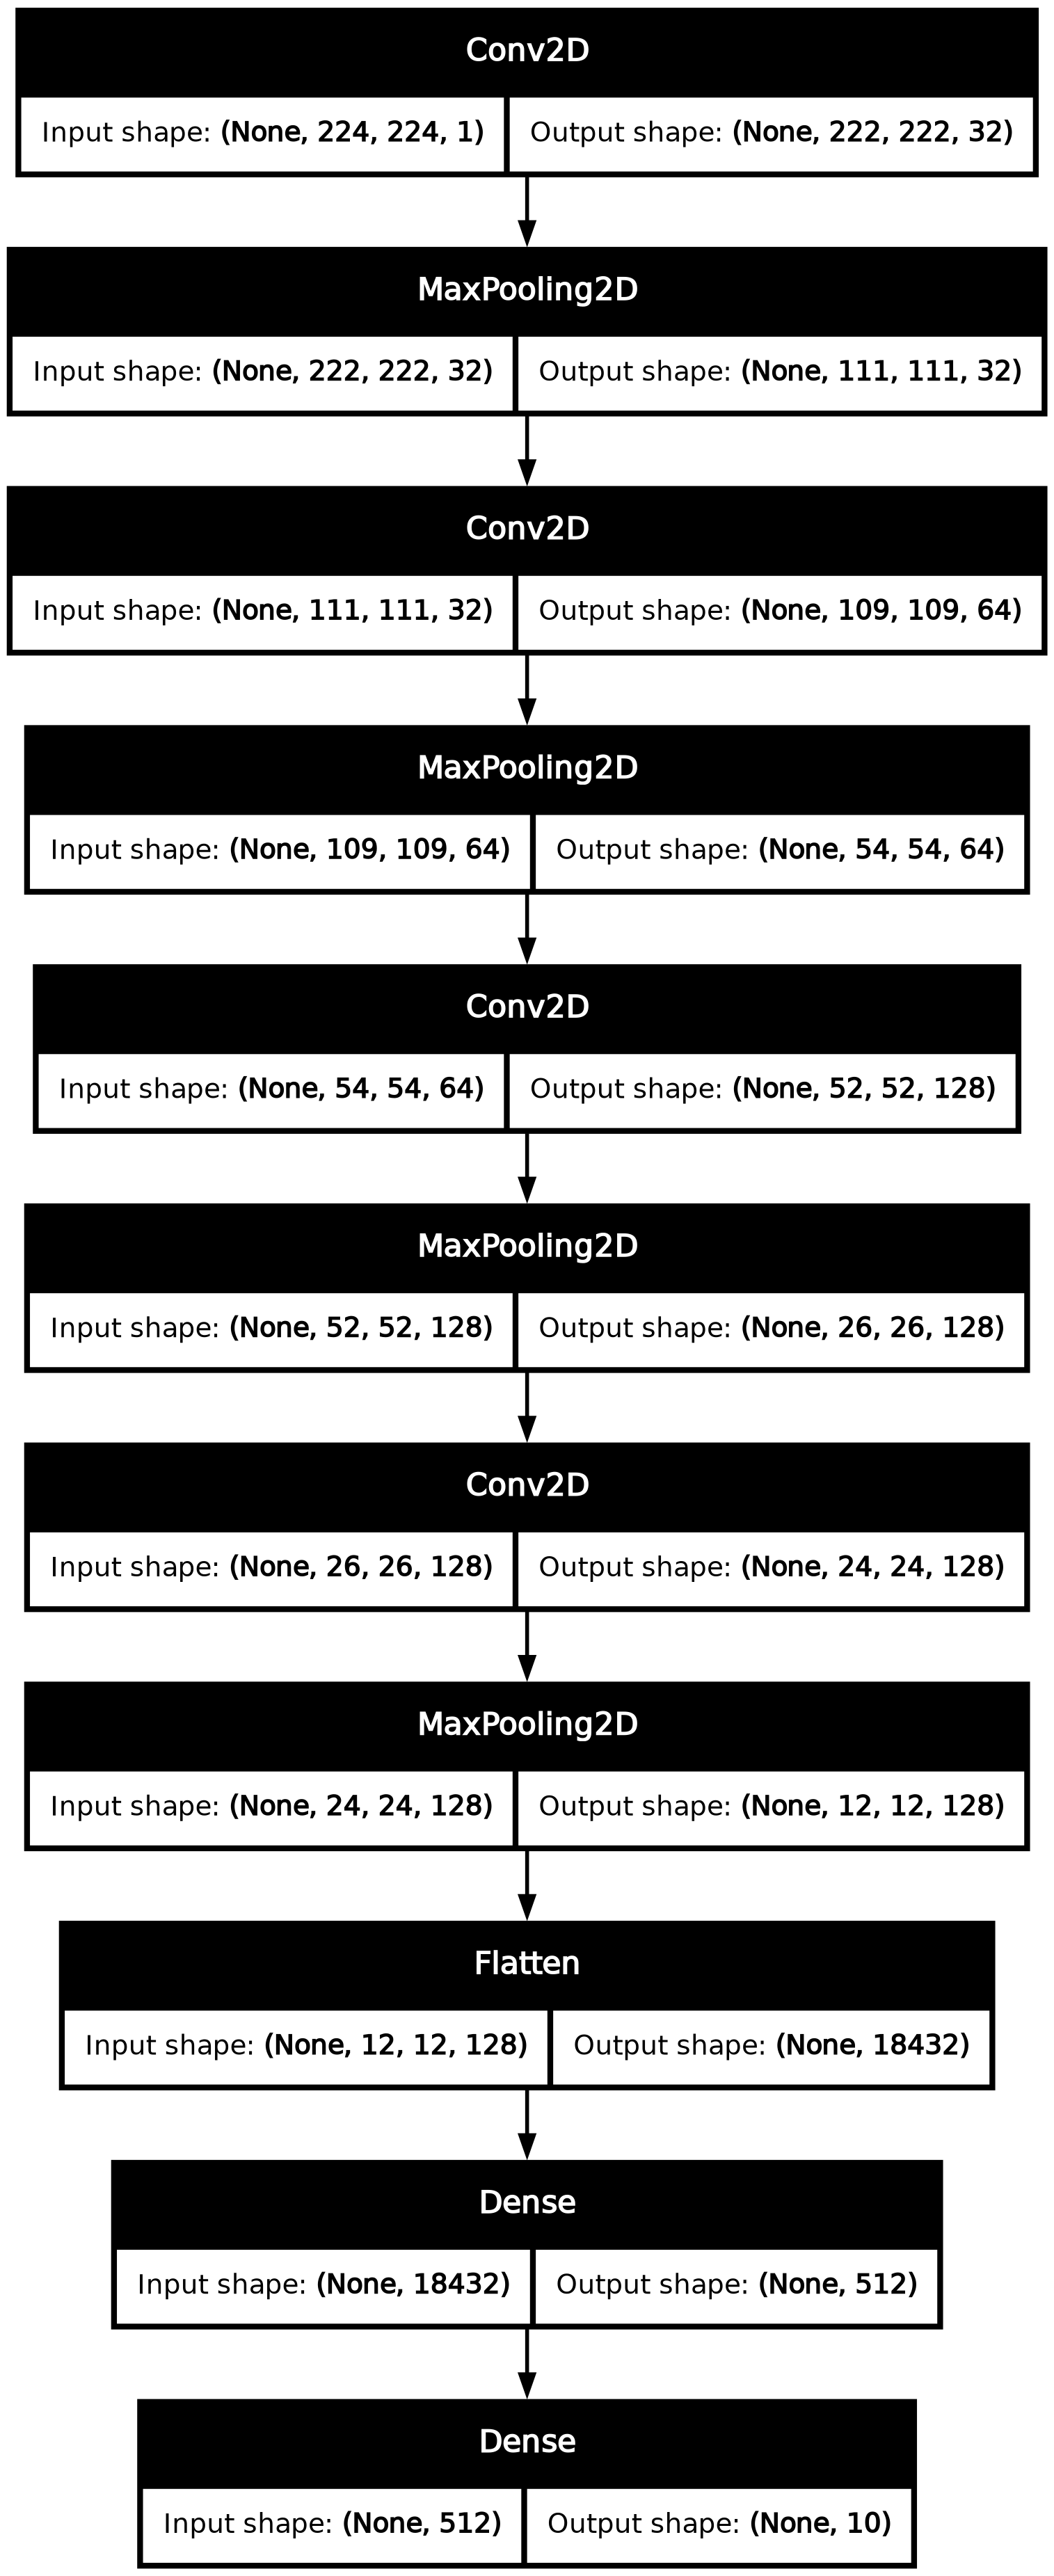

In [12]:
model_img_file = './results_and_models/Basic_CNN.png'
tf.keras.utils.plot_model(model, to_file=model_img_file,
                          show_shapes=True,
                          show_layer_activations=False,
                          show_dtype=False,
                          show_layer_names=False)

#### Basic CNN Training

In [13]:
#Check GPU
!nvidia-smi

Wed May  6 13:01:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   32C    P0             31W /   70W |   13865MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
!find / -type f -name "libdevice.10.bc" 2>/dev/null

/opt/conda/lib/python3.12/site-packages/triton/backends/nvidia/lib/libdevice.10.bc
/opt/conda/nvvm/libdevice/libdevice.10.bc


In [15]:
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/opt/conda'

In [25]:
tf.config.run_functions_eagerly(True)

In [26]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=RMSprop(learning_rate=1e-4),
              metrics=['acc'],
              jit_compile=False
             )

In [15]:
filepath = './results_and_models/basic_cnn/weights.{epoch:02d}-{val_loss:.2f}.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_loss',
    verbose=0,
    save_best_only=False,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch'
)

In [28]:
images_train_np = np.asarray(images_train).astype('float32')

In [19]:
labels_train_np = np.asarray(labels_train).astype('float32')

In [29]:
history = model.fit(images_train, labels_train, epochs=5)

/opt/conda/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/5


2026-05-06 13:06:01.186718: W tensorflow/core/framework/op_kernel.cc:1829] UNKNOWN: JIT compilation failed.
2026-05-06 13:06:01.190117: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: UNKNOWN: JIT compilation failed.


UnknownError: {{function_node __wrapped__Sqrt_device_/job:localhost/replica:0/task:0/device:GPU:0}} JIT compilation failed. [Op:Sqrt] name: 

In [ ]:
history = model.fit(
    images_train,
    epochs=100,
    validation_data=images_valid,
    validation_steps=8,
    callbacks=[checkpoint],
    verbose=2
)